let's create a model that can detect brain tumor
we have 253 Brain MRI images in the data set which 155 of those images are in the folder yes that means they have tumor and 98 Brain MRI images are in the folder no which mean they are non-tumorous.

# let's import the packages

In [1]:
!pip install imutils



In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf

In [4]:
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import imutils 
import cv2
from os import listdir
import warnings
warnings.filterwarnings("ignore")


# let's prepare and preprocess the data

first let's crop the image so only the part of the image that contains the brain can stand out

In [5]:
def crop_brain_contour(image, plot=False):
    
    #convert the image to grayscale, and blur it a little bit
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5),0)
    
    # let's remove any noise that mean if an image is blury we have to make it more visible by 
    # thresholding the image and then a series of dimunition(erosions) and dilations
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    #find contours in thresholded image, then grab the largest one
    conts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    conts = imutils.grab_contours(conts)
    c= max(conts, key=cv2.contourArea)
    
    # find the extreme points
    left = tuple(c[c[:, :, 0].argmin()][0])
    right = tuple(c[c[:, :, 0].argmax()][0])
    top = tuple(c[c[:, :, 1].argmin()][0])
    bot = tuple(c[c[:, :, 1].argmax()][0])
    
    # let's crop new image out of the original image using the four extreme point above
    new_image = image[top[1]:bot[1], left[0]:right[0]]
    
    # let's plot the image
    if plot:
        plt.figure()
        
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        
        plt.tick_params(axis='both', which='both',
                        top= False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        
        plt.title('Original Image')
        
        plt.subplot(1,2,2)
        plt.imshow(new_image)
        
        plt.tick_params(axis='both', which='both',
                        top= False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Cropped Image')
        
        plt.show()
    return new_image


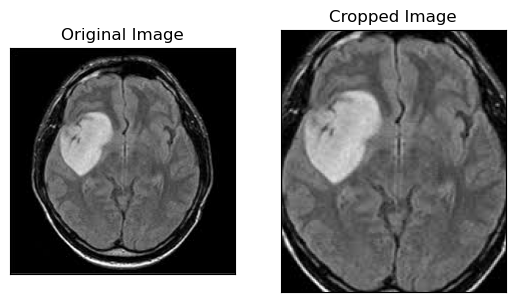

In [6]:
img = cv2.imread('yes/Y4.jpg')
ex_new_img = crop_brain_contour(img, True)



# let's load up the data
we would want to resize our image so they can have all the exact size knowing they all have different sizes.
we will read images, resize them and normalize them meaning our pixel values will be scaled to range 0-1

In [7]:
# so our function will contain two parameters one for directory path and the other onw for the size
def load_data(dir_list, image_size):
    # let's load all the image in our directory
    X = []
    y = []
    image_width, image_height = image_size
    for directory in dir_list:

        for filename in listdir(directory):
            # load images
            image = image = cv2.imread(directory + '\\' + filename)


            # let's crop the brain from the entire image
            image = crop_brain_contour(image, plot=False)
            # let's resize the images
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)
            # if the image is in the named 'yes', let's appenda value of one to the target array
            # otherwise append 0
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])
    X=np.array(X)
    y=np.array(y)
    
    # we don't want our data to be in order, let's shuffle it
    X, y = shuffle(X, y)
    
    print(f'Number of example is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')
    
    return X, y
            

let's load up the data that we augmented earlier

In [8]:
augmented_path = 'archive/'



# augmented data (yes and no) contains both original images and the cropped ones
augmented_yes = augmented_path + 'yes'
augmented_no = augmented_path + 'no'


IMG_WIDTH, IMG_HEIGHT = (240, 240)



X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))



Number of example is: 253
X shape is: (253, 240, 240, 3)
y shape is: (253, 1)


As shown above we have 253 images. each images has a shape of (253, 240,3)=(image_width,image_height, number_of_channels)

# let's see our sample images from files

In [9]:
def plot_sample_images(X, y, n=50):
    """
    X: A numpy array with shape = (#_example, image_width, image_height, #_channels)
    y: A numpy array with shape = (#_example,1)
    
    """
    for label in [0,1]:
        #grab the first n images with the corresponding y valuesn equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)
        
        plt.figure(figsize=(20,10))
        
        i = 1 #current plot
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            #remove ticks
            plt.tick_params(axis='both', which='both',
                           top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)
            
            i += 1
            
            label_to_str = lambda label: 'Yes' if label == 1 else 'No'
            plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

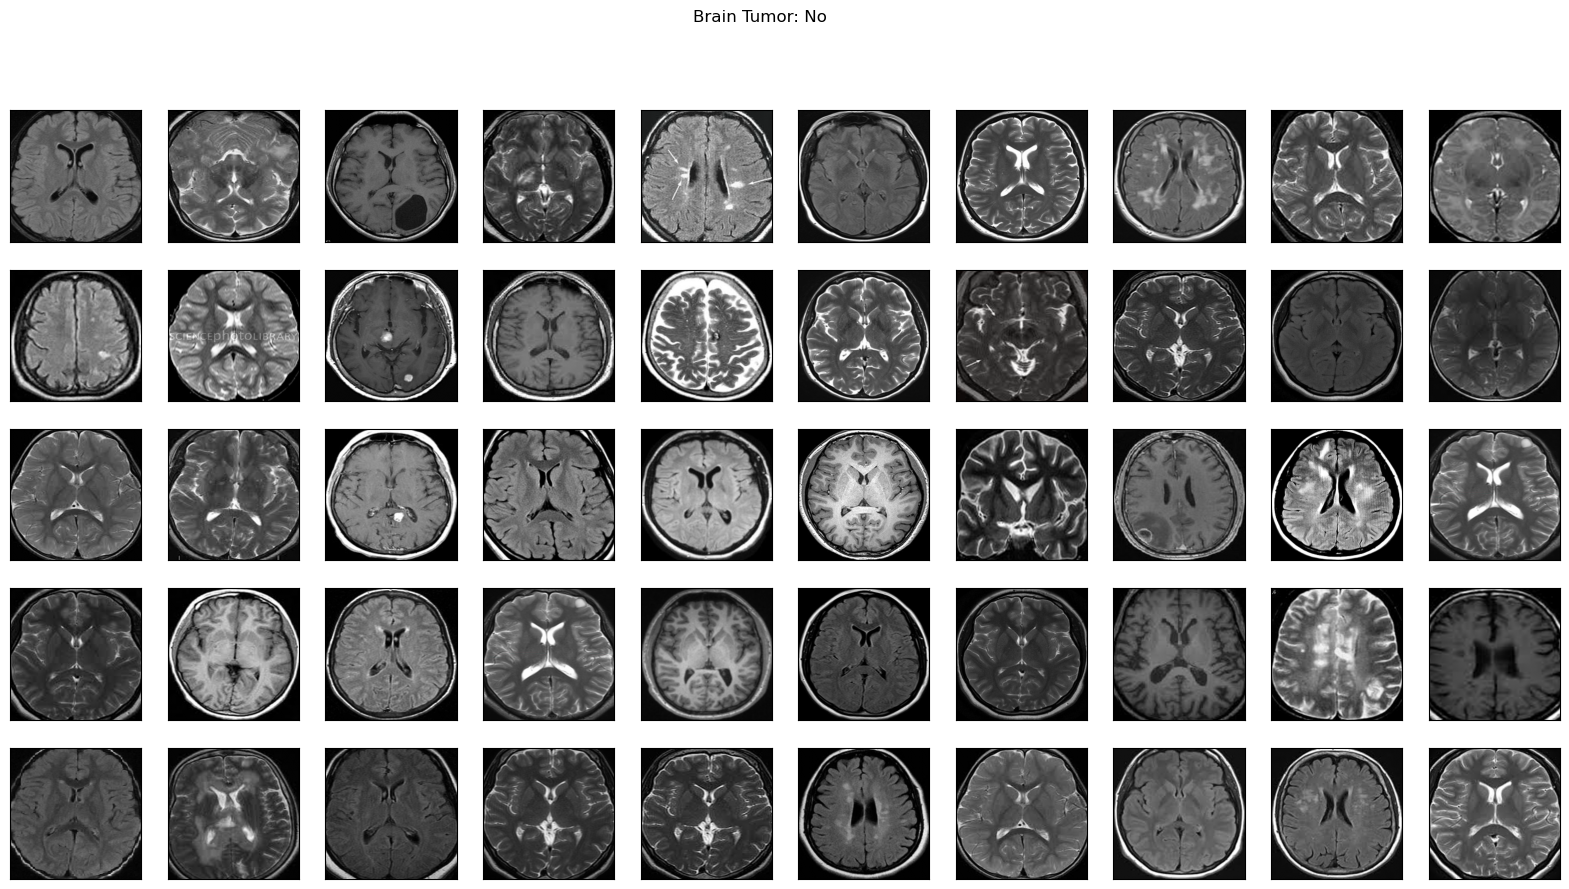

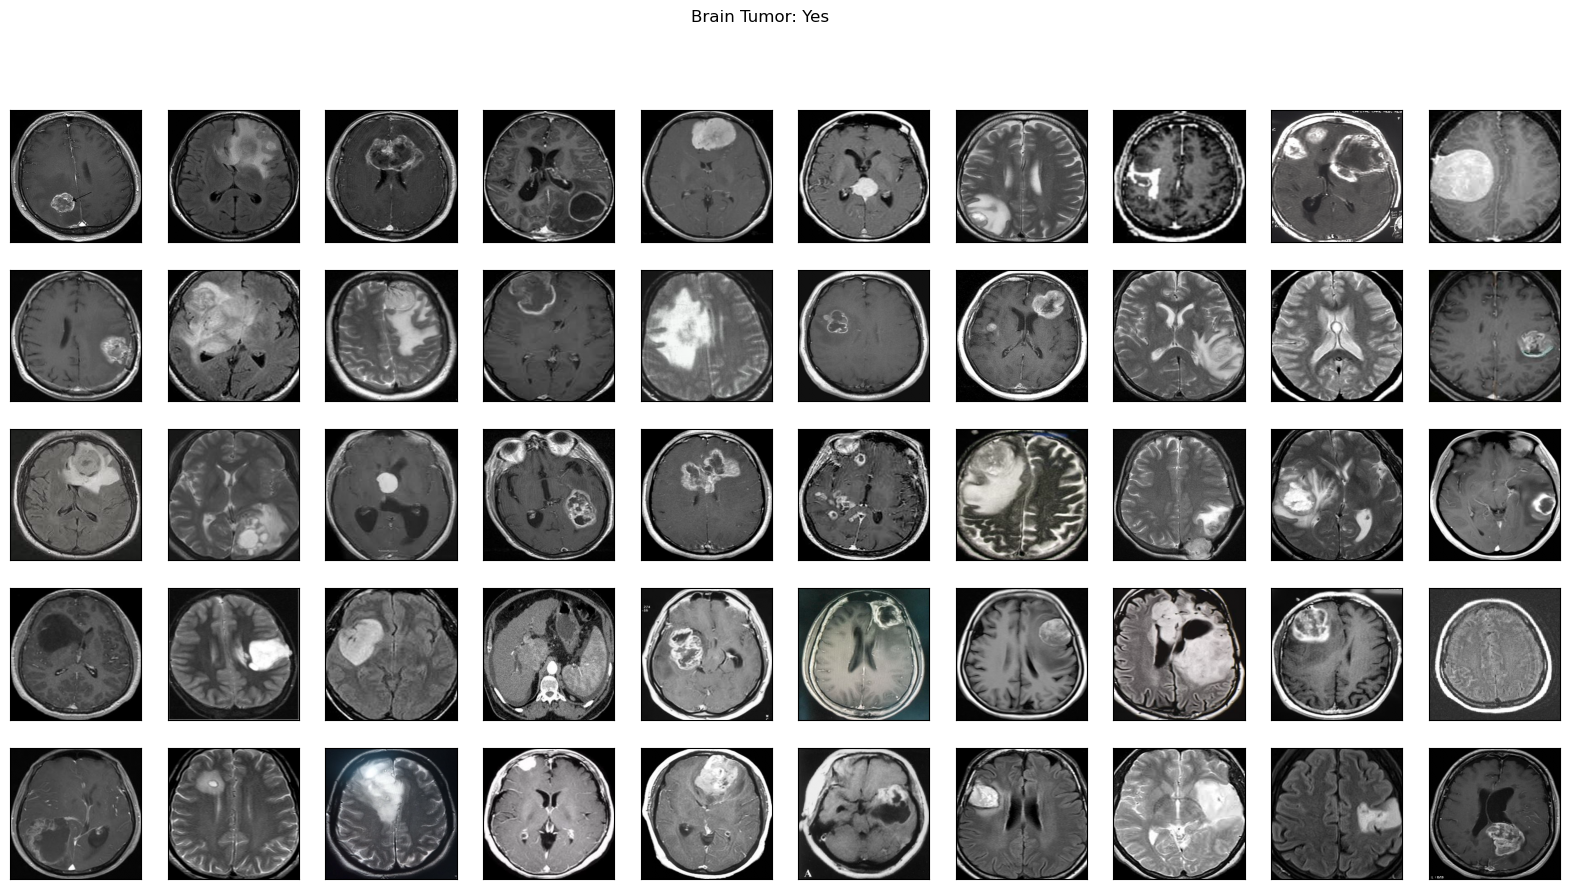

In [10]:
plot_sample_images(X, y)


# Let's split the data

In [11]:
def split_data(X,y, test_size=0.2):
    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)
    
    return X_train, y_train, X_val, y_val,  X_test, y_test

1. 70% of the data for training
2. 15% of the data for validation
3. 15% of the data for testing

In [12]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [13]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 177
number of development examples = 38
number of test examples = 38
X_train shape: (177, 240, 240, 3)
Y_train shape: (177, 1)
X_val (dev) shape: (38, 240, 240, 3)
Y_val (dev) shape: (38, 1)
X_test shape: (38, 240, 240, 3)
Y_test shape: (38, 1)


In [14]:
# let's nicely format the time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [15]:
def compute_f1_score(y_true, prob):
    y_pred = np.where(prob > 0.5, 1, 0)
    
    score = f1_score(y_true, y_pred)
    return score

# let's build our model

In [16]:
def build_model(input_shape):
    """"
    Arugments:
        input_shape: A tuple representing the shape of the input of the model. shape=(image_width, image_height, #_channels)
    Returns:
        model: A Model object.
    """
    #Define the placeholder as a tensor with shape input_shape
    X_input = Input(input_shape)

    # let's pad the border of x_input with zeroes
    X = ZeroPadding2D((2,2))(X_input)

    # conv -> BN -> RELU Block applied to x
    X = Conv2D(32, (7,7), strides = (1,11), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = "bn0")(X)
    X = Activation('relu')(X)
    
    # Maxpool
    X = MaxPooling2D((4,4), name='max_pool0')(X)
    
    # Maxpool
    X = MaxPooling2D((4,4), name='max_pool1')(X)
    
    #Flatten X
    X = Flatten()(X)
    #FullyConnected
    X = Dense(1, activation='sigmoid', name='fc')(X)
    
    #let's create our keras model instance to use the instance to train/test our model
    model = Model(inputs = X_input, outputs = X, name='BrainDetectionModel')
    
    return model

In [17]:
# let's define the image shape
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

In [18]:
model = build_model(IMG_SHAPE)

In [19]:
model.summary()

Model: "BrainDetectionModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 240, 240, 3)]     0         
                                                                 
 zero_padding2d (ZeroPadding  (None, 244, 244, 3)      0         
 2D)                                                             
                                                                 
 conv0 (Conv2D)              (None, 238, 22, 32)       4736      
                                                                 
 bn0 (BatchNormalization)    (None, 238, 22, 32)       128       
                                                                 
 activation (Activation)     (None, 238, 22, 32)       0         
                                                                 
 max_pool0 (MaxPooling2D)    (None, 59, 5, 32)         0         
                                               

In [20]:
# let's compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
# tensorboard
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [22]:
# checkpoint
# unique file name that will include the epoch and the validation (development) accuracy
filepath="models/cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}.model"

#save the model with the best validation (development) accuracy till now
checkpoint = ModelCheckpoint('models/{}.model'.format(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max'))

## let's train the model

In [23]:
start_time = time.time()

In [33]:
from keras.callbacks import LearningRateScheduler

# Define a learning rate schedule function
def lr_schedule(epoch):
    lr = 0.1
    if epoch > 10:
        lr *= 0.001
    elif epoch > 5:
        lr *= 0.5
    return lr

# Create a LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

# Fit the model with learning rate schedule callback
history = model.fit(x=X_train, y=y_train, batch_size=16, epochs=20,
                    validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint, lr_scheduler])

end_time = time.time()
execution_time = (end_time - start_time)
print(f'Elapsed time: {hms_string(execution_time)}')

Epoch 1/20
11/12 [==========================>...] - ETA: 0s - loss: 0.6307 - accuracy: 0.6477

INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-01-0.74.model.model\assets


INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-01-0.74.model.model\assets


12/12 [==============================] - 4s 321ms/step - loss: 0.6308 - accuracy: 0.6497 - val_loss: 0.5818 - val_accuracy: 0.7368 - lr: 0.1000
Epoch 2/20
11/12 [==========================>...] - ETA: 0s - loss: 0.6231 - accuracy: 0.7159

INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-02-0.71.model.model\assets


...

INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-19-0.71.model.model\assets


12/12 [==============================] - 5s 426ms/step - loss: 0.6747 - accuracy: 0.5989 - val_loss: 0.6187 - val_accuracy: 0.7105 - lr: 1.0000e-04
Epoch 20/20
11/12 [==========================>...] - ETA: 0s - loss: 0.6758 - accuracy: 0.5966

INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-20-0.71.model.model\assets


INFO:tensorflow:Assets written to: models/models\cnn-parameters-improvement-20-0.71.model.model\assets


12/12 [==============================] - 5s 454ms/step - loss: 0.6747 - accuracy: 0.5989 - val_loss: 0.6188 - val_accuracy: 0.7105 - lr: 1.0000e-04
Elapsed time: 0:15:12.4


## Let's plot our training process

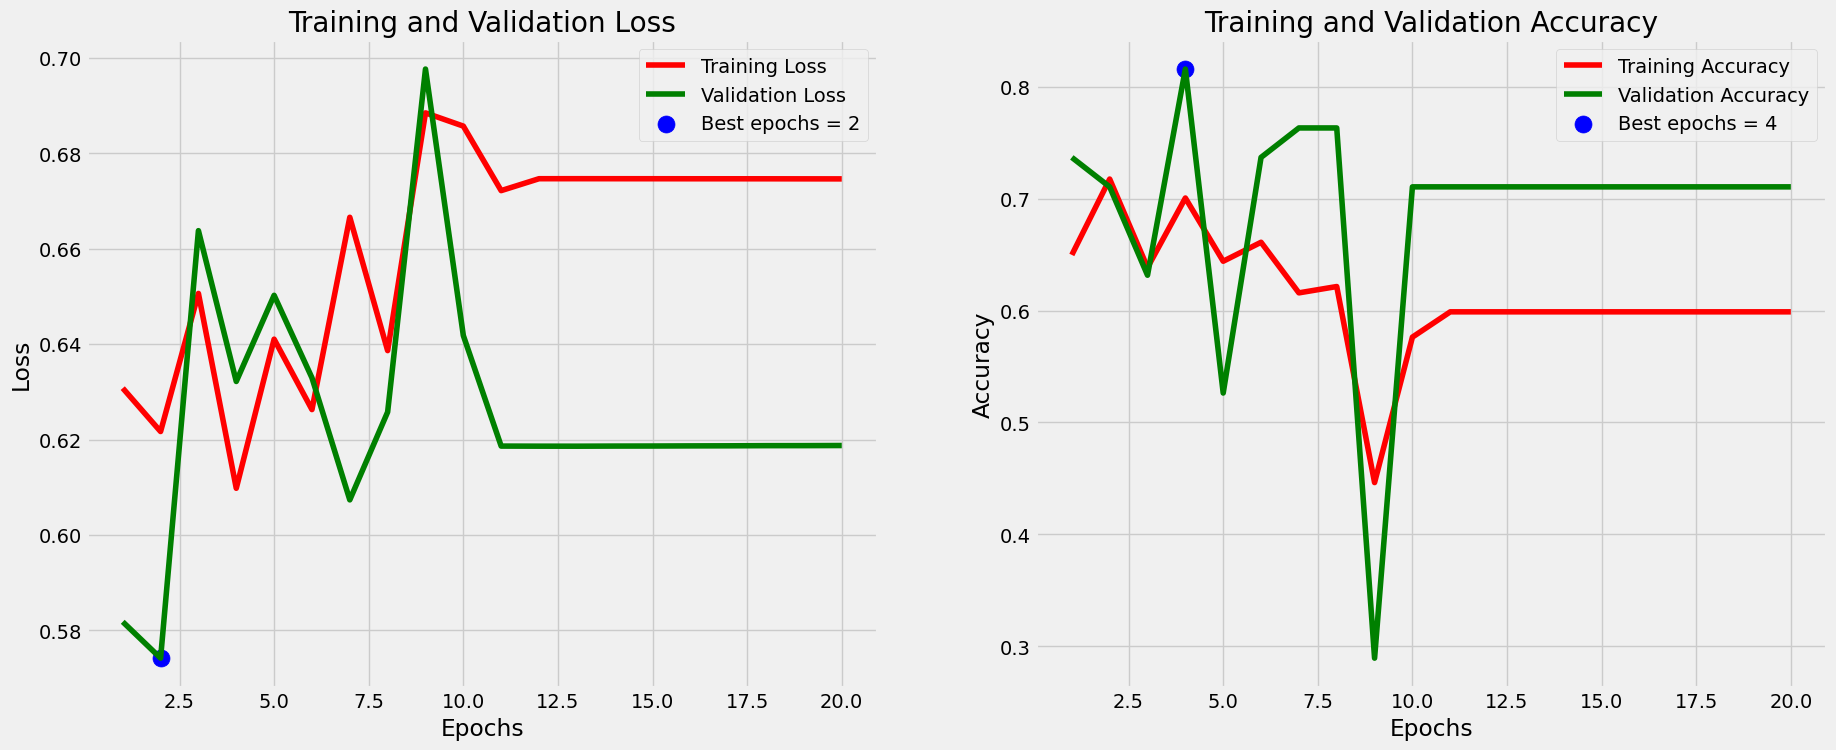

In [34]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [35]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

best_acc_percentage = val_highest * 100

print(f'Best validation accuracy: {best_acc_percentage:.2f}%')


Best validation accuracy: 81.58%


### This indicate our best validation accuracy is 81.58%


In [82]:
history= history.history
for key in history.keys():
    print(key)

loss
accuracy
val_loss
val_accuracy
lr


In [87]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5)  # Assuming binary classification, adjust threshold if needed



2/2 [==============================] - 0s 10ms/step


In [89]:
f1 = f1_score(y_test, y_pred_binary)
print("F1-score on test data:", f1)


F1-score on test data: 0.711864406779661
